In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch 
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = 'vit_h'
CHECKPOINT_PATH = '../weights/sam_vit_h_4b8939.pth'

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device= DEVICE)

mask_generator = SamAutomaticMaskGenerator(sam)

found 29 masks


(np.float64(-0.5), np.float64(959.5), np.float64(1249.5), np.float64(-0.5))

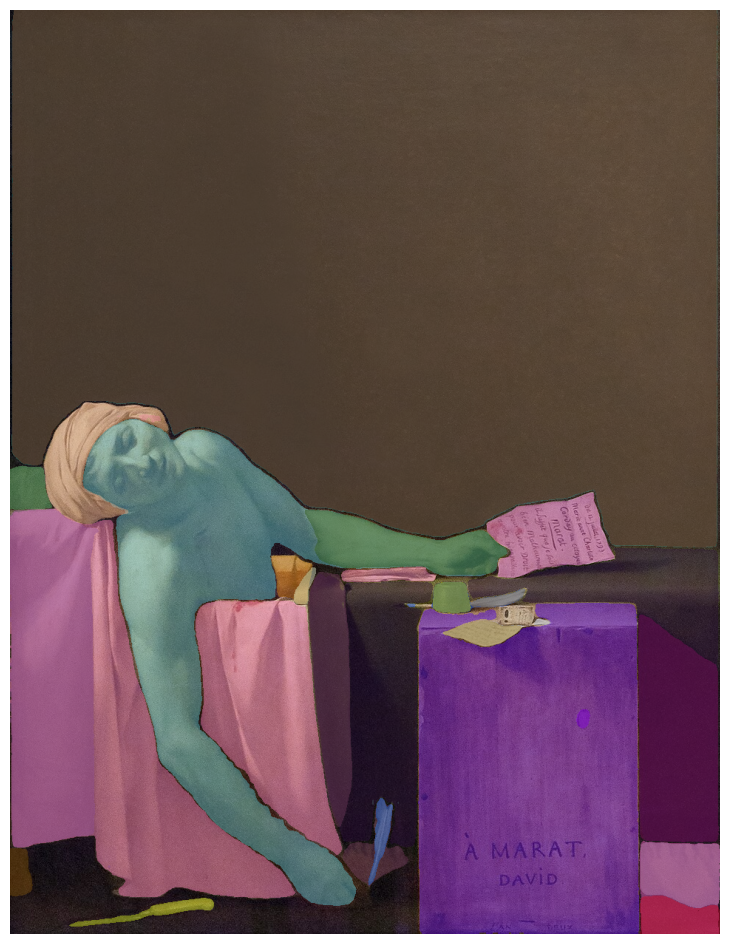

In [3]:
IMAGE_PATH = "../data/raw_images/img_16.jpg"

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

masks = mask_generator.generate(img_rgb)
print(f"found {len(masks)} masks")

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0], m.shape[1], 3))
        color_mask = np.random.random((1, 3)).tolist()[0]
        for i in range(3):
            img[:,:,i] = color_mask[i]
        ax.imshow(np.dstack((img, m*0.45))) # 0.45 è l'opacità del colore

plt.figure(figsize=(12,12))
plt.imshow(img_rgb)
show_anns(masks)
plt.axis('off')